In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
import pandas as pd
od.download("https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: paranthesis
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard


100%|██████████| 16.5M/16.5M [00:01<00:00, 16.0MB/s]


In [ ]:
df=pd.read_csv("/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")
df.head()
df.info()
df.describe()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()
df.isnull().sum()
df.fillna(0, inplace=True)
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


In [ ]:
df

,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,cancelled_rides_by_driver,incomplete_rides,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,is_cancelled,booking_frequency
0,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,1.0,237.0,5.73,NaN,NaN,UPI,1,1
2,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,0,1
3,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,0,1
4,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet,0,1
149996,Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI,0,1
149997,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash,0,1
149998,Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI,0,1


In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv')

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check column names
print("\nColumns:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Convert Date & Time Columns
# Replacing 'booking_date' with 'Date'
# ------------------------------------------

df['Date'] = pd.to_datetime(df['Date'])

# Create datetime features
df['hour'] = df['Date'].dt.hour
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['weekday'] = df['Date'].dt.day_name()

# Weekend flag
df['is_weekend'] = df['Date'].dt.weekday >= 5

# Convert True/False to 1/0
df['is_weekend'] = df['is_weekend'].astype(int)

# ------------------------------------------
# Create Cancellation Flag
# Replacing 'booking_status' with 'Booking Status'
# ------------------------------------------

df['cancelled'] = np.where(
    df['Booking Status'] == 'Cancelled',
    1,
    0
)

# ------------------------------------------
# Handle Missing Values
# ------------------------------------------

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Final dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display cleaned data
print("\nCleaned Dataset:")
print(df.head())

First 5 Rows:
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0

/tmp/ipykernel_3674/306638226.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3674/306638226.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us


Missing Values After Cleaning:
Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
hour                                 0
day                                  0
month                                0
weekday                         

is_cancelled
0    93000
1    57000
Name: count, dtype: int64


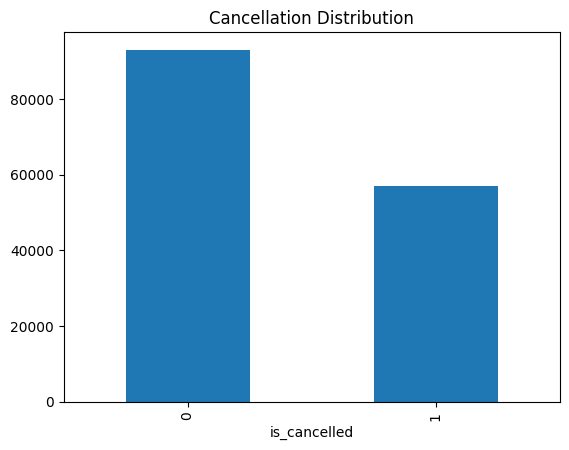

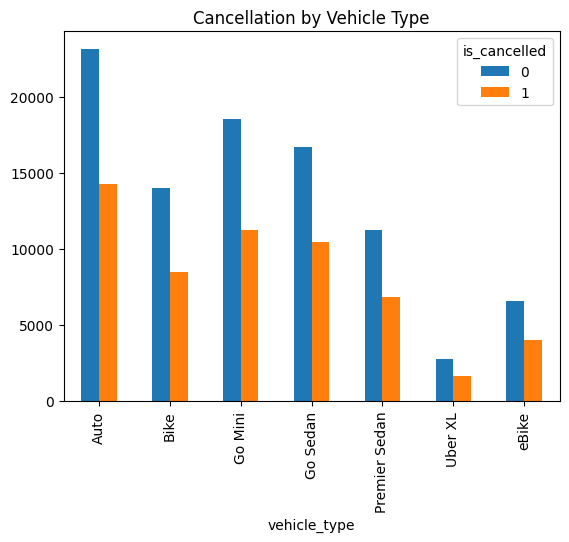

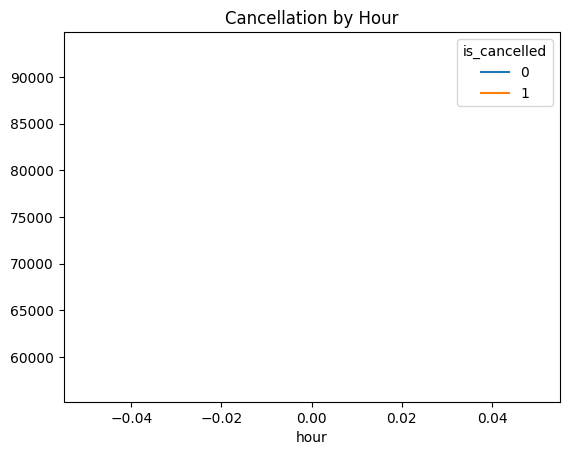

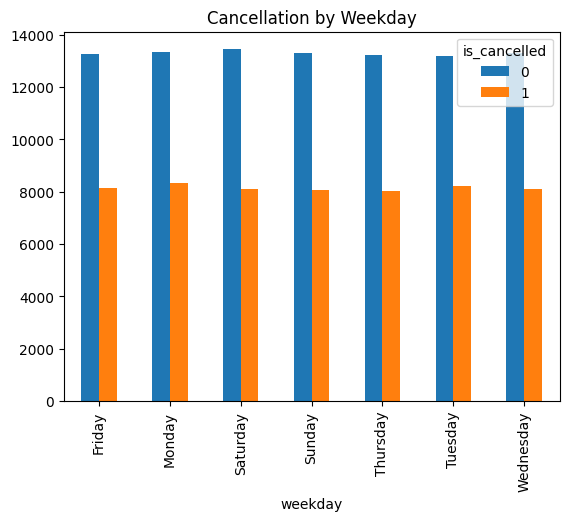

driver_ratings
3.0    0.000000
3.1    0.000000
3.2    0.000000
3.3    0.000000
3.4    0.000000
3.5    0.000000
3.6    0.000000
3.7    0.000000
3.8    0.000000
3.9    0.000000
4.0    0.000000
4.1    0.000000
4.2    0.000000
4.3    0.801902
4.4    0.000000
4.5    0.000000
4.6    0.000000
4.7    0.000000
4.8    0.000000
4.9    0.000000
5.0    0.000000
Name: is_cancelled, dtype: float64
pickup_location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64


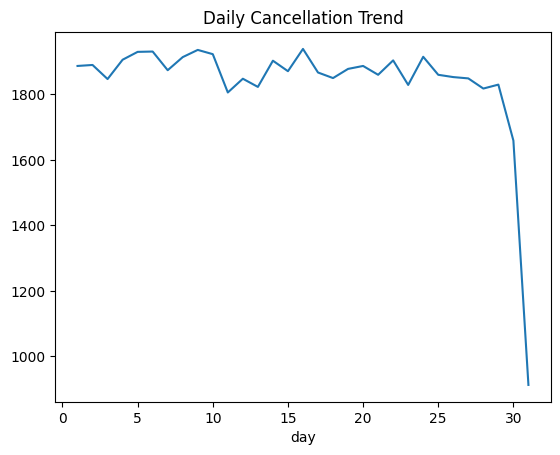

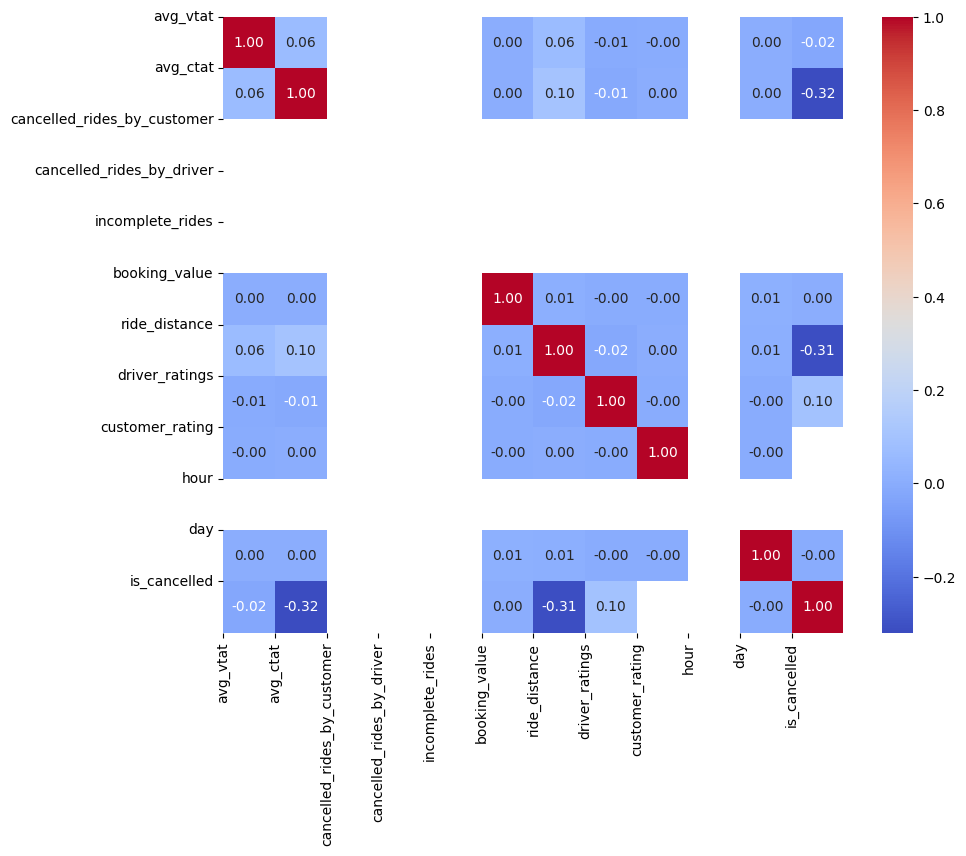

In [ ]:
# day2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.where
import seaborn as sns # Import seaborn for heatmap

# Load dataset
df = pd.read_csv("/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

# Standardize column names (strip whitespace and convert to snake_case)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Create datetime features
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

# Convert 'booking_status' column values to lowercase for consistent comparison
df['booking_status'] = df['booking_status'].str.lower()

# Create 'is_cancelled' column based on 'booking_status'
# Assuming 'completed' is not cancelled, and anything else is.
df['is_cancelled'] = np.where(df['booking_status'] == 'completed', 0, 1)

# Understand target variable
print(df['is_cancelled'].value_counts())

# Cancellation distribution
df['is_cancelled'].value_counts().plot(kind='bar')
plt.title("Cancellation Distribution")
plt.show()

# Cancellation rate by vehicle type
cancel_vehicle = pd.crosstab(
    df['vehicle_type'],
    df['is_cancelled']
)

cancel_vehicle.plot(kind='bar')
plt.title("Cancellation by Vehicle Type")
plt.show()

# Cancellation by hour
cancel_hour = pd.crosstab(
    df['hour'],
    df['is_cancelled']
)

cancel_hour.plot(kind='line')
plt.title("Cancellation by Hour")
plt.show()

# Cancellation by weekday
cancel_weekday = pd.crosstab(
    df['weekday'],
    df['is_cancelled']
)

cancel_weekday.plot(kind='bar')
plt.title("Cancellation by Weekday")
plt.show()

# Driver rating analysis
# Ensure 'driver_rating' exists and handle potential non-numeric values or NaNs if present
# For simplicity, will use the mean after imputation, if original 'driver_rating' has NaNs
# Also checking if 'driver_rating' is present in df.columns after column standardization.
if 'driver_ratings' in df.columns:
    # Assuming driver_ratings needs to be imputed before groupby mean
    df['driver_ratings'] = pd.to_numeric(df['driver_ratings'], errors='coerce')
    # Replace inplace=True with direct assignment for future Pandas compatibility
    df['driver_ratings'] = df['driver_ratings'].fillna(df['driver_ratings'].median())
    print(df.groupby('driver_ratings')['is_cancelled'].mean())
else:
    print("Column 'driver_ratings' not found after standardization.")

# Top pickup locations
print(df['pickup_location'].value_counts().head(10))

# Daily cancellation trend
daily = df.groupby('day')['is_cancelled'].sum()

daily.plot()
plt.title("Daily Cancellation Trend")
plt.show()

# Correlation Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f') # Using seaborn for a more informative heatmap

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

# plt.colorbar() # Colorbar is automatically added by sns.heatmap
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Load dataset to ensure a clean slate with original dtypes
df = pd.read_csv("/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

# Standardize column names (strip whitespace and convert to snake_case)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Convert 'booking_status' column values to lowercase for consistent comparison
df['booking_status'] = df['booking_status'].str.lower()

# Create 'is_cancelled' column based on 'booking_status'
df['is_cancelled'] = np.where(df['booking_status'] == 'completed', 0, 1)

# Generate booking frequency *before* dropping customer_id
booking_freq = df.groupby('customer_id').size()
df['booking_frequency'] = df['customer_id'].map(booking_freq).fillna(0)

# Define columns to drop (identifiers, text descriptions)
drop_final_cols = [
    'booking_id', 'customer_id', 'date', 'time', 'booking_status',
    'reason_for_cancelling_by_customer', 'driver_cancellation_reason', 'incomplete_rides_reason'
]
df = df.drop(columns=[col for col in drop_final_cols if col in df.columns])

# Now X and y
X = df.drop('is_cancelled', axis=1)
y = df['is_cancelled']

# --- Corrected Preprocessing Steps ---

# Step 1: Handle Explicit Categorical Features via One-Hot Encoding
categorical_features_to_encode = [
    'vehicle_type', 'pickup_location', 'drop_location', 'payment_method'
]

# Ensure these columns exist and are suitable for one-hot encoding.
# If a categorical column is entirely NaN, fill it with a placeholder for encoding.
# If it's not an object type (e.g., coerced to float in a previous run), convert it to string.
for col in categorical_features_to_encode:
    if col in X.columns:
        if X[col].isnull().all():
            print(f"Warning: Categorical column '{col}' is entirely NaN. Filling with 'missing' for one-hot encoding.")
            X[col] = X[col].fillna('missing')
        elif X[col].dtype != 'object':
            # Convert to string to ensure get_dummies processes it correctly
            X[col] = X[col].astype(str)

existing_categorical_cols = [col for col in categorical_features_to_encode if col in X.columns]
if existing_categorical_cols:
    X = pd.get_dummies(X, columns=existing_categorical_cols, drop_first=True)

# Step 2: Coerce any *remaining* object columns to numeric (e.g., if they contained numerical data as strings)
# Any columns that were initially categorical but not in `categorical_features_to_encode`
# and now are objects will be handled here, or columns with mixed types.
for col in X.select_dtypes(include='object').columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')


# Step 3: Impute NaNs in all numerical columns
numerical_cols_for_imputation = X.select_dtypes(include=np.number).columns

if len(numerical_cols_for_imputation) > 0:
    # Identify and explicitly fill numerical columns that are *entirely* NaN with 0.
    # This prevents SimpleImputer from skipping them and causing dimension mismatches.
    all_nan_numerical_cols = [col for col in numerical_cols_for_imputation if X[col].isnull().all()]
    if all_nan_numerical_cols:
        print(f"Warning: Numerical columns {all_nan_numerical_cols} are entirely NaN. Filling with 0.")
        X.loc[:, all_nan_numerical_cols] = X.loc[:, all_nan_numerical_cols].fillna(0)

    # Apply SimpleImputer to the remaining numerical columns that might have NaNs
    # (at this point, no numerical column should be entirely NaN)
    imputer = SimpleImputer(strategy='median')
    X.loc[:, numerical_cols_for_imputation] = imputer.fit_transform(X.loc[:, numerical_cols_for_imputation])

# Final check for NaNs before split (should be empty if clean)
print("Final NaNs in X before split (should be empty):")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Correlation analysis
corr = X.corr()
print(corr)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

# Verify NaNs in X_train and X_test after split
print("\nNaNs in X_train after split (should be empty):\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("\nNaNs in X_test after split (should be empty):\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])

# Handle class imbalance using class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))
print(class_weights)

Final NaNs in X before split (should be empty):
Series([], dtype: int64)
                             avg_vtat  avg_ctat  cancelled_rides_by_customer  \
avg_vtat                     1.000000  0.050914                          NaN   
avg_ctat                     0.050914  1.000000                          NaN   
cancelled_rides_by_customer       NaN       NaN                          NaN   
cancelled_rides_by_driver         NaN       NaN                          NaN   
incomplete_rides                  NaN       NaN                          NaN   
...                               ...       ...                          ...   
drop_location_Yamuna Bank    0.002135  0.000768                          NaN   
payment_method_Credit Card  -0.010690 -0.000963                          NaN   
payment_method_Debit Card   -0.012782  0.005731                          NaN   
payment_method_UPI          -0.028582  0.008935                          NaN   
payment_method_Uber Wallet  -0.011119  0.007475

In [ ]:
# Install XGBoost
!pip install xgboost -q

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================
# Logistic Regression
# ============================

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC :", roc_auc_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

# Overfitting / Underfitting Check

lr_train_pred = lr.predict(X_train)

train_acc = accuracy_score(y_train, lr_train_pred)
test_acc = accuracy_score(y_test, lr_pred)

print("\nTraining Accuracy :", round(train_acc,4))
print("Testing Accuracy :", round(test_acc,4))

if train_acc - test_acc > 0.10:
    print("Status : Overfitting")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Status : Underfitting")
else:
    print("Status : Balanced Model")


# ============================
# Random Forest
# ============================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n===== Random Forest =====")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC :", roc_auc_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

# Overfitting / Underfitting Check

rf_train_pred = rf.predict(X_train)

train_acc = accuracy_score(y_train, rf_train_pred)
test_acc = accuracy_score(y_test, rf_pred)

print("\nTraining Accuracy :", round(train_acc,4))
print("Testing Accuracy :", round(test_acc,4))

if train_acc - test_acc > 0.10:
    print("Status : Overfitting")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Status : Underfitting")
else:
    print("Status : Balanced Model")


# ============================
# XGBoost
# ============================

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("\n===== XGBoost =====")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision :", precision_score(y_test, xgb_pred))
print("Recall :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC :", roc_auc_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

# Overfitting / Underfitting Check

xgb_train_pred = xgb.predict(X_train)

train_acc = accuracy_score(y_train, xgb_train_pred)
test_acc = accuracy_score(y_test, xgb_pred)

print("\nTraining Accuracy :", round(train_acc,4))
print("Testing Accuracy :", round(test_acc,4))

if train_acc - test_acc > 0.10:
    print("Status : Overfitting")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Status : Underfitting")
else:
    print("Status : Balanced Model")


# ============================
# Compare Models
# ============================

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n===== Model Comparison =====")
print(results)


# ============================
# Cross Validation
# ============================

print("\n===== Cross Validation =====")

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    print("\n", name)
    print("CV Scores :", scores)
    print("Average CV Accuracy :", round(scores.mean(),4))


# ============================
# Prediction
# ============================

sample = X_test.iloc[:5]

prediction = xgb.predict(sample)

print("\nPredictions :")
print(prediction)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


===== Logistic Regression =====
Accuracy : 0.8627333333333334
Precision : 0.7784490669929642
Recall : 0.8928947368421053
F1 Score : 0.8317535545023697
ROC AUC : 0.8685710243350311

Confusion Matrix
[[15703  2897]
 [ 1221 10179]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.84      0.88     18600
           1       0.78      0.89      0.83     11400

    accuracy                           0.86     30000
   macro avg       0.85      0.87      0.86     30000
weighted avg       0.87      0.86      0.86     30000


Training Accuracy : 0.863
Testing Accuracy : 0.8627
Status : Balanced Model

===== Random Forest =====
Accuracy : 0.9657
Precision : 0.9886909810573933
Recall : 0.9202631578947369
F1 Score : 0.9532506474035709
ROC AUC : 0.9569057724957555

Confusion Matrix
[[18480   120]
 [  909 10491]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     18600


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


 Logistic Regression
CV Scores : [0.86223333 0.86306667 0.8615     0.86193333 0.86443333]
Average CV Accuracy : 0.8626

 Random Forest
CV Scores : [0.96583333 0.96416667 0.97163333 0.9639     0.96493333]
Average CV Accuracy : 0.9661

 XGBoost
CV Scores : [0.99926667 0.9994     0.99926667 0.9992     0.99906667]
Average CV Accuracy : 0.9992

Predictions :
[1 0 1 0 1]


In [ ]:
import pandas as pd

# Get the exact list of columns the model was trained on
model_features = xgb.get_booster().feature_names
# (If that doesn't work, try: model_features = xgb.feature_names_in_.tolist())

# Start with a single row of all zeros
new_data = pd.DataFrame(0, index=[0], columns=model_features)

# Fill in the numeric (non-categorical) columns directly
numeric_values = {
    'avg_vtat': 4,
    'avg_ctat': 6,
    'cancelled_rides_by_customer': 0,
    'cancelled_rides_by_driver': 0,
    'incomplete_rides': 0,
    'booking_value': 350,
    'ride_distance': 8.5,
    'driver_ratings': 4.8,
    'customer_rating': 4.7,
    'booking_frequency': 15
}

for col, val in numeric_values.items():
    new_data[col] = val

# Set the correct one-hot columns to 1 for your categorical choices
new_data['vehicle_type_Go Mini'] = 1          # example: chosen vehicle type
new_data['pickup_location_Adarsh Nagar'] = 1  # example: chosen pickup location
# new_data['drop_location_<something>'] = 1   # do the same for drop_location
# new_data['payment_method_<something>'] = 1  # and for payment_method

# Now predict
prediction = xgb.predict(new_data)
probability = xgb.predict_proba(new_data)

print("Prediction:", prediction[0])
if prediction[0] == 1:
    print("Ride will be Cancelled")
else:
    print("Ride will NOT be Cancelled")
print("Probability:", probability[0])

Prediction: 0
Ride will NOT be Cancelled
Probability: [0.99758965 0.00241033]
